In [1]:
import pandas as pd
import numpy as np
import functions_for_analyze as ffa
import single_output_parser as sop
import os
from types import SimpleNamespace
import matplotlib.pyplot as pp
from importlib import reload
from matplotlib.colors import TABLEAU_COLORS
import _daily_reporters as dr
import json
from __visuals__ import matplot
from __visuals__ import _printing_and_display_functions as pad
import _interaction_functions as IF
import _Plot_from_Tables as PFT
import Make_Interaction_Tables as MIT
import pickle

%matplotlib widget

In [2]:
style_sheet = "./__visuals__/f12xg_plot_style.mplstyle"
pp.style.use(style_sheet)

# Helper functions

In [3]:
def gen_fig_title(sysd, plot_type="Interaction energies"):
    return f"{sysd['mono1_name']}-{sysd['mono2_name']} {plot_type}"

def gen_fig_fname(sysd, ext='svg', plot_type="Interaction_energies", folder=None):
    fname= f"{sysd['mono1_name']}_{sysd['mono2_name']}_{plot_type}.{ext}"
    if folder is None:
        folder = '__Analysis_Outputs__/'
    fname = os.path.join(folder, fname)
    return fname

In [4]:
def infer_cores(sysd):
    """Infer the 'cores' list by reading the dimer's bse_data_*.csv metacsv (per base.json)."""
    dimer_bse_datafile = f"{sysd['dimer_dir']}/{sysd['method_dir']}/{sysd['basename']}"
    _, dimer_df = ffa.MakeTables.read_metacsv(
        dimer_bse_datafile, kwargs2=sysd['dimer_kwargs2']
    )
    return sorted(set(dimer_df.index.get_level_values(0)))

def build_sysd(mono1_dir, mono2_dir, dimer_dir, method_dir, bases_family,
               base_json='queryFiles/base.json', mono1_name=None, mono2_name=None):
    """Build a sysd dict via Make_Interaction_Tables.build_sysd, with 'cores' inferred from disk."""
    base = MIT.load_base_config(base_json)
    args = SimpleNamespace(
        mono1_dir=mono1_dir, mono2_dir=mono2_dir,
        dimer_dir=dimer_dir, method_dir=method_dir,
        bases_family=bases_family, base_json=base_json,
        mono1_name=mono1_name, mono2_name=mono2_name,
    )
    sysd, outer_index = MIT.build_sysd(args, base)
    sysd['outer_index'] = outer_index
    sysd['cores'] = infer_cores(sysd)
    return sysd, outer_index

In [5]:
def select_from_plot_data(plot_data, **match):
    """
    Select entries from a collect_interaction_data-style plot_data list
    ([xdata, ydata, labels], ...) whose labels match all of the given
    key=value pairs. Returns fresh (list) copies so the originals and the
    caller's added labels (e.g. a 'method' tag) don't interfere.
    """
    selected = []
    for x, y, labels in plot_data:
        if all(labels.get(k) == v for k, v in match.items()):
            selected.append([x, y, dict(labels)])
    return selected

In [6]:
def get_available_gammas(sysd):
    """
    Discover the outer_index (e.g. 'gammas' or 'gamma_set') values actually
    present on disk for this sysd, by reading one core's combined csv
    without slicing down to a single value. Excludes the 'Difference'
    pseudo-value added by combine_systems/add_sum_and_difference.

    F12's 'gammas' values are numeric and sort numerically; XG's
    'gamma_set' values are compound strings (e.g. '1.00_1.00_1.00') and
    sort lexically.
    """
    outer_index = sysd['outer_index']
    core = sysd['cores'][0]
    fname_sysd = dict(sysd, core=core)
    fname = IF.get_combined_outfile_name(fname_sysd)
    _, df = ffa.MakeTables.read_metacsv(
        fname, kwargs2=dict(header=[0, 1], index_col=[0, 1, 2])
    )

    values = [v for v in df.index.get_level_values(outer_index).unique() if v != 'Difference']
    try:
        return sorted(values, key=float)
    except (TypeError, ValueError):
        return sorted(values)

In [7]:
def assign_new_total(df, key1, key2, label):
    """Returns a fresh copy of df with `label` assigned as key2+key1.

    Always copies df first: some upstream dfs (e.g. dfs_xg's per
    core/gamma_set .xs() slices) are still flagged by pandas as
    possibly-a-view, which makes an in-place `df[label] = ...` raise
    SettingWithCopyWarning. Copying up front sidesteps that regardless of
    how the caller's df was produced.
    """
    df = df.copy()
    _, cbs_df = IF.get_HF_and_best_from_multimer_df(df, key1=key1, key2=key2)
    df[label] = cbs_df
    return df

In [8]:
def get_total(df, totkey=None, xs_key=None):
    if totkey is None:
        totkey = ('Correlation Energy', '3')

    if xs_key is not None:
        dfie = df.xs(key=xs_key)[totkey]
    else:
        dfie = df[totkey]

    return dfie.index.values.astype(np.float16), dfie.values

# System

In [ ]:
mono1_dir = 'interactions/ne_ar/ne'
mono2_dir = 'interactions/ne_ar/ar'
dimer_dir = 'interactions/ne_ar/dimer'

reload(PFT)
reload(MIT)
reload(IF)

# Load Data

The full dataset for DFMP2, F12, and XG is loaded once here. The
Interaction Energies and Total Energies sections below only read from
these variables, so either section can be run independently (in any
order) once this section has run.

- DFMP2 is the only method with `core-valence` (`aug-cc-pwCVXZ`) data
  loaded, since it's the only method that needs it (Ne-Ar interaction
  Summary section, comparing basis families).
- F12 and XG only ever use `valence` (`aug-cc-pVXZ`) data.


## DFMP2

In [10]:
sysd_dfmp2_cv, _ = build_sysd(mono1_dir, mono2_dir, dimer_dir, 'dfmp2', bases_family='core-valence')
dfs_dfmp2_cv = PFT.get_dfs(sysd_dfmp2_cv)

sysd_dfmp2_pv, _ = build_sysd(mono1_dir, mono2_dir, dimer_dir, 'dfmp2', bases_family='valence')
dfs_dfmp2_pv = PFT.get_dfs(sysd_dfmp2_pv)

## F12

In [11]:
sysd_f12, _ = build_sysd(mono1_dir, mono2_dir, dimer_dir, 'f12', bases_family='valence')
gammas_f12 = get_available_gammas(sysd_f12)
dfs_f12_by_gamma = {g: PFT.get_dfs(sysd_f12, gamma=g) for g in gammas_f12}

## XG

In [12]:
sysd_xg, _ = build_sysd(mono1_dir, mono2_dir, dimer_dir, 'xg', bases_family='valence')
gamma_sets_xg = get_available_gammas(sysd_xg)
dfs_xg_by_gamma_set = {gs: PFT.get_dfs(sysd_xg, gamma=gs) for gs in gamma_sets_xg}

In [ ]:
pad.header(3, "F12 Gammas")
for key in gammas_f12:
    print(f"{key}")
pad.header(3, "XG Gamma sets")
for key in gamma_sets_xg:
    print(f"{key}")

# Interaction Energies

## DFMP2 (Ne-Ar)

### Filter and get plot data

In [ ]:
filter_specs = dict(
    cross_filters={
        "func_kwargs": [
            dict(totkey=("HF + ", "CorrE(CBS)")),
            dict(totkey=("Reference Energy", "5"))
        ],
        "core": ["all electron", "frozen"],
    },
)

filter_specs['common_filter'] = {"basis": "aug-cc-pVXZ"}
filters = ffa.expand_filter_grid(**filter_specs)
plot_data_dfmp2 = IF.collect_interaction_data(dfs_dfmp2_pv, filters)

filter_specs['common_filter'] = {"basis": "aug-cc-pwCVXZ"}
filters = ffa.expand_filter_grid(**filter_specs)
plot_data_dfmp2 += IF.collect_interaction_data(dfs_dfmp2_cv, filters)

### Plot with Legend

In [ ]:
styles0 = {# common styles for all
    "basis" : {
        "aug-cc-pVXZ" : dict(color='tab:blue', label='pVXZ', linewidth=2),
        "aug-cc-pwCVXZ" : dict(color='tab:orange', label='pwCVXZ'),
    },
    "core" : {
        "frozen" : dict(marker='x', label='frozen'),
        "all electron"  : dict(marker='s', fillstyle='none', label='all e')
    }
}

styles = dict(styles0)
styles.update(
    {
        "totkey": {
            ("HF + ", "CorrE(CBS)") : dict(linestyle='-', label='HF5+CBS'),
            ("Reference Energy", "5") : dict(linestyle=':', label='HF5'),
        }
    }
)
                                         

In [ ]:
fig, ax, leg_ax = PFT.plot_with_external_style_legend(plot_data_dfmp2, styles, convert=10**(3))
ax.set_ylim(-0.5, 0.2)
ax.set_ylabel(rf"Energy (mH)")
ax.set_xlim(3,4.25)
ax.set_xlabel(r"Distance, $r$ $(\AA)$")
fig.suptitle(gen_fig_title(sysd_dfmp2_pv))

## Summary

* Frozen and all electron interaction energies are similar for pwCVXZ
* DFMP2 with pVXZ overestimates binding energy in the CBS limit for all electron
* But the frozen core approximation gives similar results to pwCVXZ case

### Take away: Use `DFMP2 aug-cc-pwCVXZ HF5 + CBS` as reference
  

In [ ]:
ref_plot_data_dfmp2 = []
for x,y,kwargs in plot_data_dfmp2:
    if kwargs['basis'] == 'aug-cc-pwCVXZ' and kwargs['totkey'] == ('HF + ', 'CorrE(CBS)'):
        ref_plot_data_dfmp2.append([x, y, kwargs])

In [ ]:
for x,y,kwargs in ref_plot_data_dfmp2:
    print(kwargs)

## F12

In [ ]:
keys_and_label = [('Correlation Energy', '3'), ('Reference Energy', '3'), ('HF3 +', 'CorrE(3)')]

### Assign new total energy

In [ ]:
for gamma in gammas_f12:
    for values in dfs_f12_by_gamma[gamma].values():
        values['df'] = assign_new_total(values['df'], *keys_and_label)

### Filter and get plot data

In [ ]:
filter_specs = dict(
    cross_filters={
        "func_kwargs": [
            dict(totkey=("HF + ", "CorrE(CBS)")),
            dict(totkey=keys_and_label[-1]),
        ],
        "core": ["frozen"],
    },
)

plot_data_f12_by_gamma = {}
for gamma in gammas_f12:
    filter_specs['common_filter'] = {"basis": "aug-cc-pVXZ", "gammas": gamma}
    filters = ffa.expand_filter_grid(**filter_specs)
    plot_data_f12_by_gamma[gamma] = IF.collect_interaction_data(dfs_f12_by_gamma[gamma], filters)

## XG

### Assign new total energy

In [ ]:
for gs in gamma_sets_xg:
    for values in dfs_xg_by_gamma_set[gs].values():
        values['df'] = assign_new_total(values['df'], *keys_and_label)

### Filter and get plot data

In [ ]:
plot_data_xg_by_gamma_set = {}
for gs in gamma_sets_xg:
    filter_specs['common_filter'] = {"basis": "aug-cc-pVXZ", "gamma_set": gs}
    filters = ffa.expand_filter_grid(**filter_specs)
    plot_data_xg_by_gamma_set[gs] = IF.collect_interaction_data(dfs_xg_by_gamma_set[gs], filters)

# Interaction Energy: DFMP2 vs F12 vs XG (HF+CBS)

#### Input: Choosing plot data from comparison

In [ ]:
chosen_gamma = {
    "F12": list(plot_data_f12_by_gamma.keys()),
    "XG": ["1.90_1.50_1.70"],
}

compare_totkey_dict = {
    "DFMP2": ("HF + ", "CorrE(CBS)"),
}

compare_basis_dict = {
    "DFMP2": "aug-cc-pwCVXZ",
}

plot_data_dict = {
    "DFMP2": plot_data_dfmp2,
}
for method, gs in chosen_gamma.items():
    for g in gs:
        if method == 'F12':
            plot_data_dict[f"{method}_{g}"] = plot_data_f12_by_gamma[g]
        else:
            plot_data_dict[f"{method}_{g}"] = plot_data_xg_by_gamma_set[g]

        compare_totkey_dict[f"{method}_{g}"] = keys_and_label[-1]
        compare_basis_dict[f"{method}_{g}"] = "aug-cc-pVXZ"

#### Code: building `plot_data_compare`

In [ ]:
plot_data_compare = []
for method_label, pdata in plot_data_dict.items():
    subset = select_from_plot_data(
        pdata,
        totkey=compare_totkey_dict[method_label],
        basis=compare_basis_dict[method_label],
        core="frozen",
    )
    for _, _, labels in subset:
        labels["method"] = method_label
    plot_data_compare += subset


#### Formatting: Styles for plot

In [ ]:
cmap_f12 = pp.get_cmap('tab10')
colors_f12 = [cmap_f12(i) for i in range(cmap_f12.N)]
cmap_xg = pp.get_cmap('Greys_r')
colors_xg = [cmap_xg(i) for i in range(cmap_xg.N)]

method_colors = {"F12": colors_f12, "XG": colors_xg}

method_style_template = {
  "F12": dict(
      marker='+', markeredgewidth=1.5,
      linestyle='-', linewidth=1
  ),
  "XG": dict(
      marker='x', markeredgewidth=2,
      linewidth=2, linestyle='-'
  ),
}

styles_compare = {
  "method": {
      "DFMP2": dict(
          color='gray',
          linestyle='--', linewidth=3,
          marker='s', fillstyle="none", markeredgewidth=2 ,
          label='DFMP2-CBS'),
  },
}

for method, gs in chosen_gamma.items():
    colors = method_colors[method]
    gamma_word = r"$\gamma$" if method == "F12" else r"$\gamma_1,\gamma_2,\gamma_3$"
    for i, g in enumerate(gs):
        style = dict(method_style_template[method])
        style['color'] = colors[i]
        g_label = str(g).replace("_",",")
        style['label'] = rf'{method} ({gamma_word}$={g_label}$)'
        styles_compare["method"][f"{method}_{g}"] = style


### Plot with Legend

In [ ]:
fig, ax, leg_ax = PFT.plot_with_external_style_legend(plot_data_compare, styles_compare, convert=10**(3))
ax.set_ylabel(rf"Energy (mH)")
ax.set_xlabel(r"Distance, $r$ $(\AA)$")
ax.set_ylim(-0.25, 0.05)
ax.set_xlim(3.1,4.)
fig_title = f"Interaction: DFMP2-CBS vs F12 and XG (frozen core aug-cc-pV{keys_and_label[0][1]}Z)"
fig.suptitle(gen_fig_title(sysd_xg, plot_type=fig_title))
fig.set_size_inches(12,8)

for _,_, labs in plot_data_compare:
    pad.header(3, labs['method'])
    things = ""
    for lab in list(labs.values()):
        things += f" | {str(lab)}"

    pad.header(4,  things)

fig_int_e = fig

In [ ]:
with open(f"__Analysis_Outputs__/{fig_title}.pkl", "wb") as f:
    pickle.dump(fig_int_e, f)

# Total Energies: DFMP2 vs F12 vs XG

Independent of the Interaction Energies section above: only reads from
the Load Data section. `keys_and_label` is specific to the interaction
section (it's the `assign_new_total` args); here we only need the raw
correlation-energy column, so we use a separate `total_energy_totkey`.


In [13]:
total_energy_totkey = ('Correlation Energy', '3')

## DFMP2

In [14]:
filter_specs = dict(
    cross_filters={
        "func_kwargs": [
            dict(totkey=("Correlation Energy", "BSE")),
        ],
        "core": ["frozen"],
    },
)
filter_specs['common_filter'] = {"basis": "aug-cc-pwCVXZ"}
filters = ffa.expand_filter_grid(**filter_specs)
plot_data_te_dfmp2 = IF.collect_interaction_data(
    dfs_dfmp2_cv, filters, func=get_total, xs_key="Dimer distances", totkey=("Correlation Energy", "BSE")
)

## F12

In [15]:
filter_specs = dict(
    cross_filters={
        "func_kwargs": [
            dict(totkey=total_energy_totkey),
        ],
        "core": ["frozen"],
    },
)

plot_data_te_f12_by_gamma = {}
for gamma in gammas_f12:
    filter_specs['common_filter'] = {"basis": "aug-cc-pVXZ", "gammas": gamma}
    filters = ffa.expand_filter_grid(**filter_specs)
    plot_data_te_f12_by_gamma[gamma] = IF.collect_interaction_data(
        dfs_f12_by_gamma[gamma], filters, func=get_total, xs_key='Dimer distances')

## XG

### Filter and get plot data

In [16]:
plot_data_te_xg_by_gamma_set = {}
for gs in gamma_sets_xg:
    filter_specs['common_filter'] = {"basis": "aug-cc-pVXZ", "gamma_set": gs}
    filters = ffa.expand_filter_grid(**filter_specs)
    plot_data_te_xg_by_gamma_set[gs] = IF.collect_interaction_data(
        dfs_xg_by_gamma_set[gs], filters, func=get_total, xs_key='Dimer distances')

# Total Energy: DFMP2 vs F12 vs XG

In [17]:
chosen_gamma_te = {
    "F12": list(plot_data_te_f12_by_gamma.keys()),
    "XG": ["1.00_1.00_1.00"],
}

compare_totkey_dict_te = {
    "DFMP2": ("Correlation Energy", "BSE"),
}

compare_basis_dict_te = {
    "DFMP2": "aug-cc-pwCVXZ",
}

plot_data_dict_te = {
    "DFMP2": plot_data_te_dfmp2,
}
for method, gs in chosen_gamma_te.items():
    for g in gs:
        if method == 'F12':
            plot_data_dict_te[f"{method}_{g}"] = plot_data_te_f12_by_gamma[g]
        else:
            plot_data_dict_te[f"{method}_{g}"] = plot_data_te_xg_by_gamma_set[g]

        compare_totkey_dict_te[f"{method}_{g}"] = total_energy_totkey
        compare_basis_dict_te[f"{method}_{g}"] = "aug-cc-pVXZ"

#### Code: building `plot_data_compare_te`

In [18]:
plot_data_compare_te = []
for method_label, pdata in plot_data_dict_te.items():
    subset = select_from_plot_data(
        pdata,
        totkey=compare_totkey_dict_te[method_label],
        basis=compare_basis_dict_te[method_label],
        core="frozen",
    )
    for _, _, labels in subset:
        labels["method"] = method_label
    plot_data_compare_te += subset


#### Formatting: Styles for plot

In [19]:
cmap_f12 = pp.get_cmap('tab10')
colors_f12 = [cmap_f12(i) for i in range(cmap_f12.N)]
cmap_xg = pp.get_cmap('Greys_r')
colors_xg = [cmap_xg(i) for i in range(cmap_xg.N)]

method_colors_te = {"F12": colors_f12, "XG": colors_xg}

method_style_template_te = {
  "F12": dict(
      marker='+', markeredgewidth=1.5,
      linestyle='-', linewidth=1
  ),
  "XG": dict(
      marker='x', markeredgewidth=2,
      linewidth=2, linestyle='-'
  ),
}

styles_compare_te = {
  "method": {
      "DFMP2": dict(
          color='gray',
          linestyle='--', linewidth=3,
          marker='s', fillstyle="none", markeredgewidth=2 ,
          label='DFMP2-CBS'),
  },
}

for method, gs in chosen_gamma_te.items():
    colors = method_colors_te[method]
    gamma_word = r"$\gamma$" if method == "F12" else r"$\gamma_1,\gamma_2,\gamma_3$"
    for i, g in enumerate(gs):
        style = dict(method_style_template_te[method])
        style['color'] = colors[i]
        g_label = str(g).replace("_",",")
        style['label'] = rf'{method} ({gamma_word}$={g_label}$)'
        styles_compare_te["method"][f"{method}_{g}"] = style


### Plot with Legend

In [20]:
ymin = 100
ymax = -100
for x, y, labs in plot_data_compare_te:
    if min(y) < ymin:
        ymin = min(y)
    if max(y) > ymax:
        ymax = max(y)

ymin, ymax

(np.float64(-0.5742726569606886), np.float64(-0.545407597466))

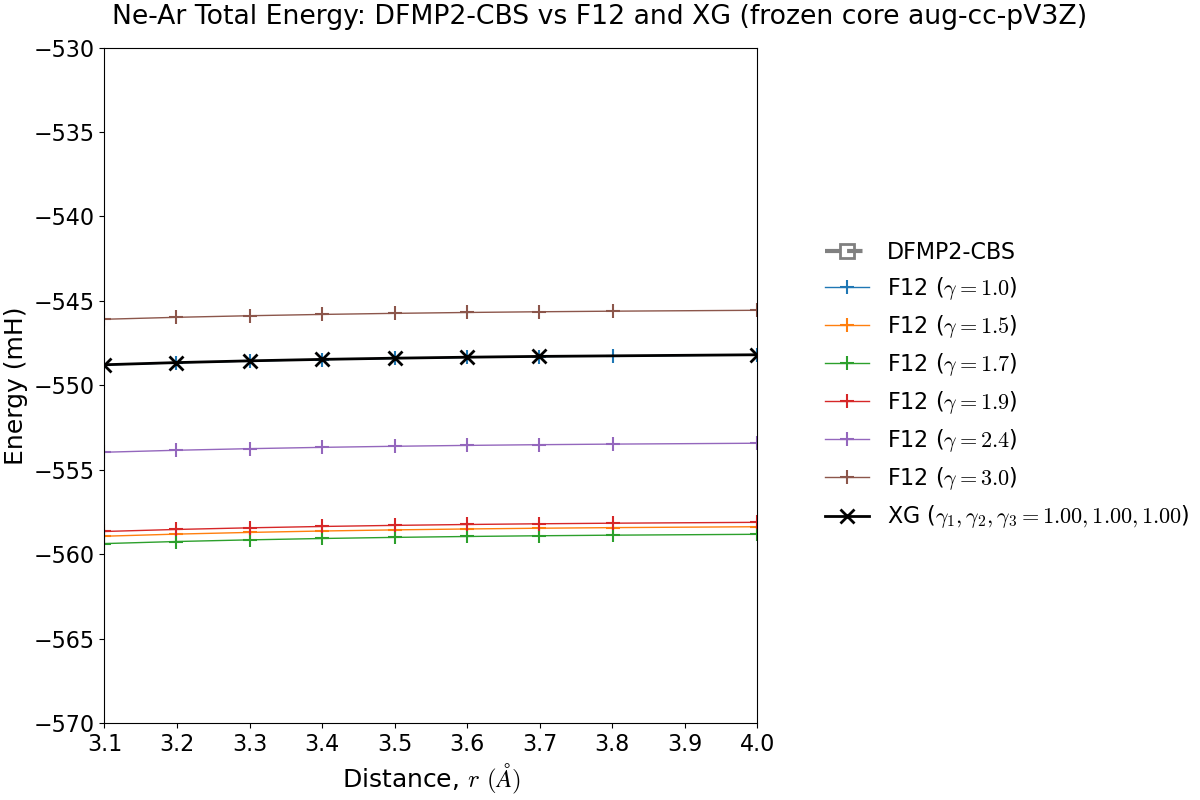

In [21]:
fig, ax, leg_ax = PFT.plot_with_external_style_legend(plot_data_compare_te, styles_compare_te, convert=10**(3))
ax.set_ylabel(rf"Energy (mH)")
ax.set_xlabel(r"Distance, $r$ $(\AA)$")
ax.set_ylim(-570, -530)
ax.set_xlim(3.1,4.)
fig_title = f"Total Energy: DFMP2-CBS vs F12 and XG (frozen core aug-cc-pV{total_energy_totkey[1]}Z)"
fig.suptitle(gen_fig_title(sysd_xg, plot_type=fig_title))
fig.set_size_inches(12,8)

for _,_, labs in plot_data_compare_te:
    pad.header(3, labs['method'])
    things = ""
    for lab in list(labs.values()):
        things += f" | {str(lab)}"

    pad.header(4,  things)

fig_total_e = fig

In [ ]:
with open(f"__Analysis_Outputs__/{fig_title}.pkl", "wb") as f:
    pickle.dump(fig_total_e, f)